In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import platform
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

---

### <center> 1. EDA 

---

#### <center> 1-1 제품의 수명 주기 확인

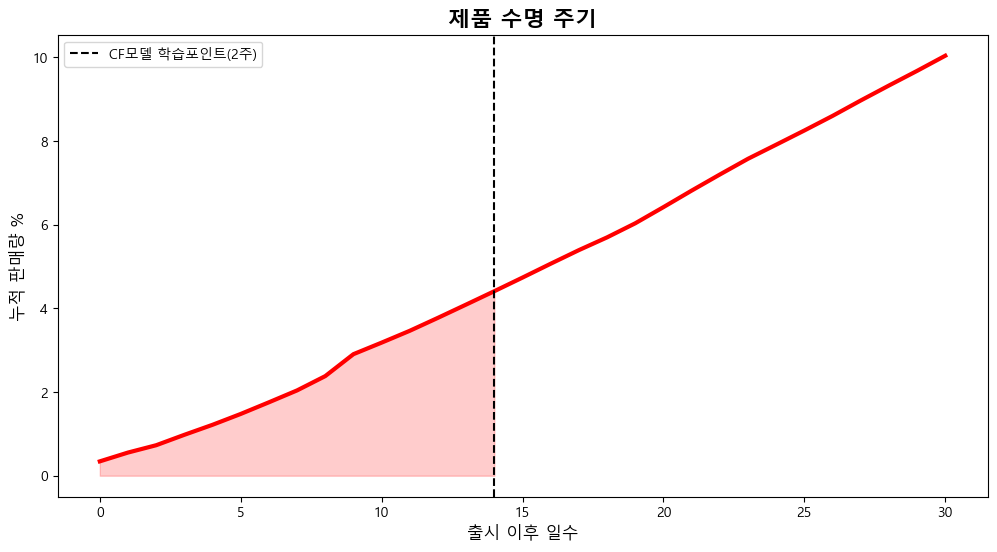

In [7]:
# 데이터 로드
transactions = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\transactions.parquet')

# 상품별 최초 판매일(출시일) 계산
first_sales = transactions.groupby('article_id')['t_dat'].min().reset_index()
first_sales.columns = ['article_id', 'first_sale_date']

# 원본 데이터와 병합하여 '출시 후 경과일' 계산
tx_life = transactions.merge(first_sales, on='article_id')
tx_life['days_since_launch'] = (tx_life['t_dat'] - tx_life['first_sale_date']).dt.days

# 출시 후 기간별 누적 판매량 비율 계산 (Top 1000 베스트셀러 기준)
top_articles = tx_life['article_id'].value_counts().head(1000).index
tx_top = tx_life[tx_life['article_id'].isin(top_articles)]

lifecycle_sales = tx_top.groupby('days_since_launch').size().reset_index(name='daily_sales')
lifecycle_sales['cumulative_sales'] = lifecycle_sales['daily_sales'].cumsum()
lifecycle_sales['sales_ratio'] = lifecycle_sales['cumulative_sales'] / lifecycle_sales['daily_sales'].sum() * 100

# 시각화 (출시 후 30일까지만 줌인)
plt.figure(figsize=(12, 6))
sns.lineplot(data=lifecycle_sales[lifecycle_sales['days_since_launch'] <= 30], 
             x='days_since_launch', y='sales_ratio', color='red', linewidth=3)

plt.axvline(x=14, color='black', linestyle='--', label='CF모델 학습포인트(2주)')
plt.title('제품 수명 주기', fontsize=16, fontweight='bold')
plt.xlabel('출시 이후 일수', fontsize=12)
plt.ylabel('누적 판매량 %', fontsize=12)
plt.fill_between(lifecycle_sales['days_since_launch'][:15], lifecycle_sales['sales_ratio'][:15], alpha=0.2, color='red')
plt.legend()
plt.show()

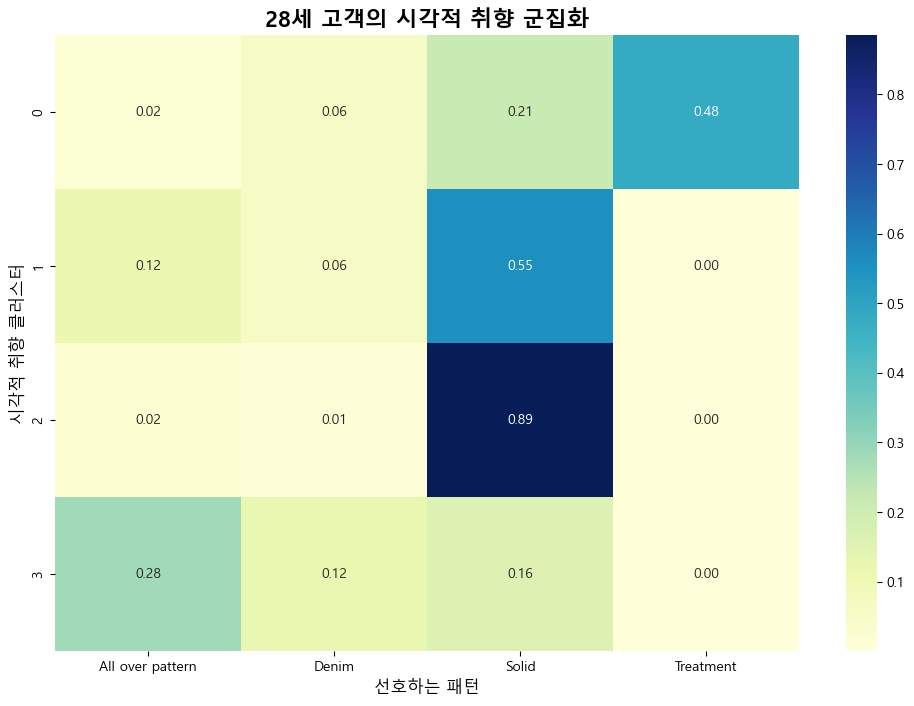

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 원본 텍스트 유지를 위해 articles.csv 활용 (숫자 라벨링된 Parquet 대신)
articles_raw = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\articles.csv', usecols=['article_id', 'graphical_appearance_name'])
customers = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\customers.parquet')
transactions = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\transactions.parquet')

# 거래 데이터에 원본 텍스트 병합
merged_df = transactions[['customer_id', 'article_id']].merge(
    customers[['customer_id', 'age_group', 'age']], on='customer_id'
).merge(
    articles_raw, on='article_id'
)

# 예시) 28세 타겟팅 및 피벗 
age_target_df = merged_df[merged_df['age'] == 28]
visual_prefs = age_target_df.groupby(['customer_id', 'graphical_appearance_name']).size().unstack(fill_value=0)
visual_prefs_ratio = visual_prefs.div(visual_prefs.sum(axis=1), axis=0)

# 색별 클러스터링
kmeans = KMeans(n_clusters=4, random_state=42)
visual_prefs_ratio['visual_tribe'] = kmeans.fit_predict(visual_prefs_ratio)

# 시각화
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=visual_prefs.columns)
# 너무 비중이 적은 마이너 패턴은 가독성을 위해 제외 (최대 비중 10% 이상인 패턴만)
cluster_centers = cluster_centers.loc[:, cluster_centers.max() > 0.1] 

plt.figure(figsize=(12, 8))
sns.heatmap(cluster_centers, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('28세 고객의 시각적 취향 군집화', fontsize=16, fontweight='bold')
plt.xlabel('선호하는 패턴', fontsize=12)
plt.ylabel('시각적 취향 클러스터', fontsize=12)
plt.show()

<Figure size 1400x700 with 0 Axes>

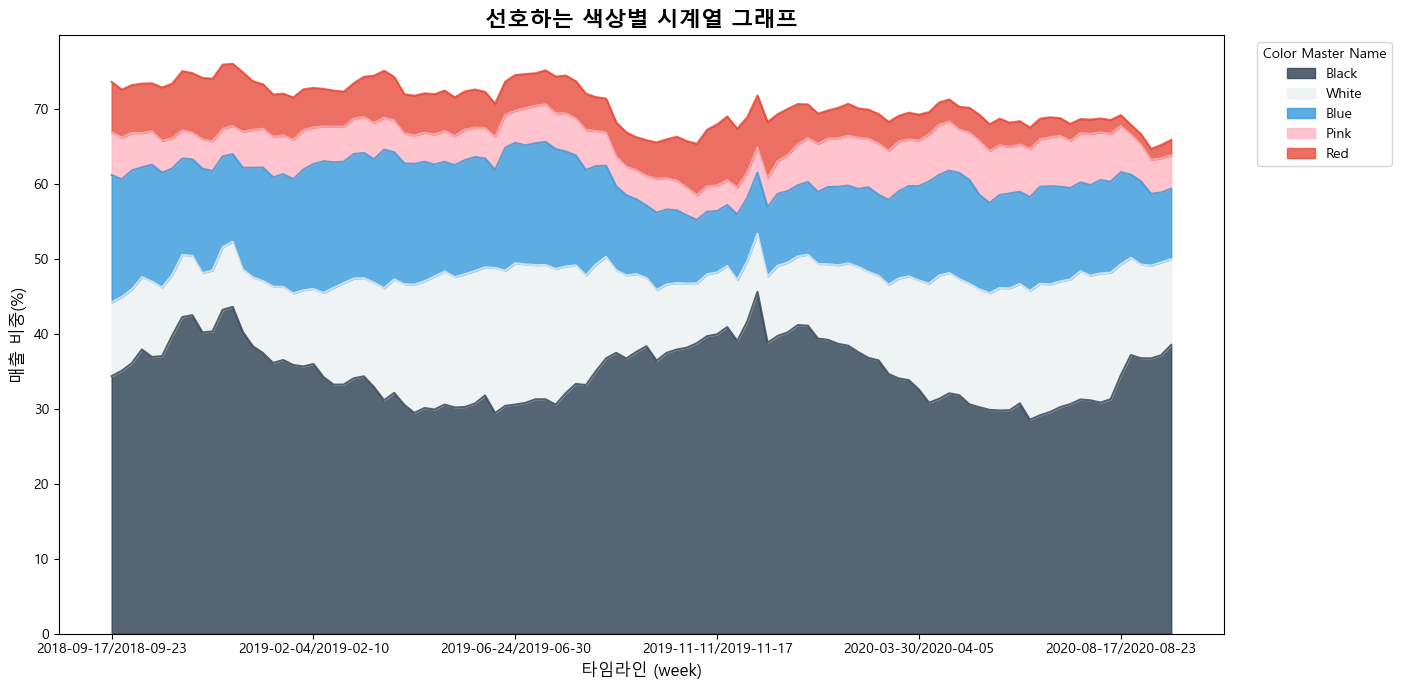

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드 (articles_parquet 파일엔 색상을 숫자로 라벨링해둬서 원본 csv파일 잠깐 사용)
transactions = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\transactions.parquet')
articles_raw = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\articles.csv', usecols=['article_id', 'perceived_colour_master_name'])

# 거래 데이터에 원본 색상 맵핑
df = transactions[['t_dat', 'article_id']].merge(
    articles_raw, on='article_id'
)
df['year_week'] = df['t_dat'].dt.to_period('W').astype(str)

# 주차별 주요 색상 판매 비율 계산
color_weekly = df.groupby(['year_week', 'perceived_colour_master_name']).size().unstack(fill_value=0)
color_weekly_ratio = color_weekly.div(color_weekly.sum(axis=1), axis=0) * 100

# 주요 색상 5개만 필터링 (블랙,화이트,블루,핑크,레드)
top_colors = ['Black', 'White', 'Blue', 'Pink', 'Red']
color_weekly_ratio = color_weekly_ratio[top_colors]

# 시각화
plt.figure(figsize=(14, 7))
color_weekly_ratio.plot(kind='area', stacked=True, figsize=(14, 7), 
                        color=['#2C3E50', '#ECF0F1', '#3498DB', '#FFB6C1', '#E74C3C'], alpha=0.8)

plt.title('선호하는 색상별 시계열 그래프', fontsize=16, fontweight='bold')
plt.xlabel('타임라인 (week)', fontsize=12)
plt.ylabel('매출 비중(%)', fontsize=12)
plt.legend(title='Color Master Name', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

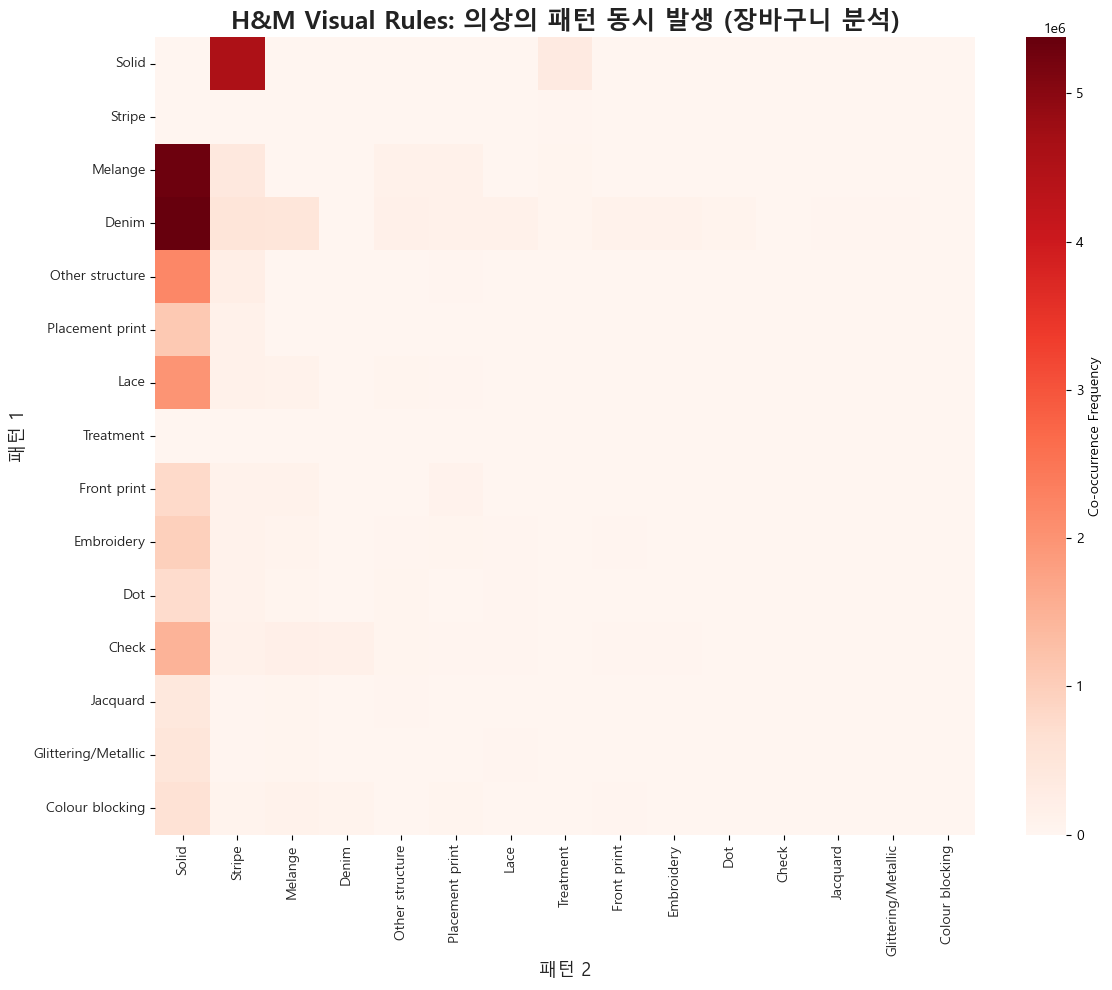

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations

# 1. 에러 원인 해결: 패턴 이름(graphical_appearance_name)을 명확히 불러옵니다!
articles_raw = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\articles.csv', usecols=['article_id', 'graphical_appearance_name'])

# 텍스트 라벨 기준으로 장바구니 데이터 생성
basket_df = transactions[['customer_id', 't_dat', 'article_id']].merge(
    articles_raw, on='article_id'
)

# 장바구니 리스트화
baskets = basket_df.groupby(['customer_id', 't_dat'])['graphical_appearance_name'].apply(list).reset_index()
baskets = baskets[baskets['graphical_appearance_name'].apply(len) >= 2]

# 동시 발생 행렬 계산
co_occurrence = Counter()
for items in baskets['graphical_appearance_name']:
    for pair in combinations(sorted(items), 2):
        co_occurrence[pair] += 1

# 데이터프레임 변환 및 피벗
co_df = pd.DataFrame(co_occurrence.keys(), columns=['Pattern_1', 'Pattern_2'])
co_df['Frequency'] = co_occurrence.values()
co_matrix = co_df.pivot(index='Pattern_1', columns='Pattern_2', values='Frequency').fillna(0)

# 시각화
plt.figure(figsize=(12, 10))

co_matrix_arr = co_matrix.values.copy() 
np.fill_diagonal(co_matrix_arr, 0) # 대각선 0 처리
co_matrix_visual = pd.DataFrame(co_matrix_arr, index=co_matrix.index, columns=co_matrix.columns)

top_patterns = co_matrix_visual.sum().nlargest(15).index # 빈도가 너무 낮은 하위 조합은 가독성을 위해 제거 (상위 15개 패턴만 시각화)
co_matrix_visual = co_matrix_visual.loc[top_patterns, top_patterns]

# H&M 톤앤매너 셋팅: Purples -> Reds 로 변경하여 H&M 시그니처 컬러 강조
hm_black = '#222222'
sns.heatmap(co_matrix_visual, cmap='Reds', annot=False, 
            cbar_kws={'label': 'Co-occurrence Frequency'})

plt.title('H&M Visual Rules: 의상의 패턴 동시 발생 (장바구니 분석)', fontsize=18, fontweight='bold', color=hm_black)
plt.xlabel('패턴 2', fontsize=13, color=hm_black)
plt.ylabel('패턴 1', fontsize=13, color=hm_black)

# 축 라벨 색상도 깔끔한 블랙으로 통일
plt.xticks(color=hm_black)
plt.yticks(color=hm_black)

plt.tight_layout()
plt.show()

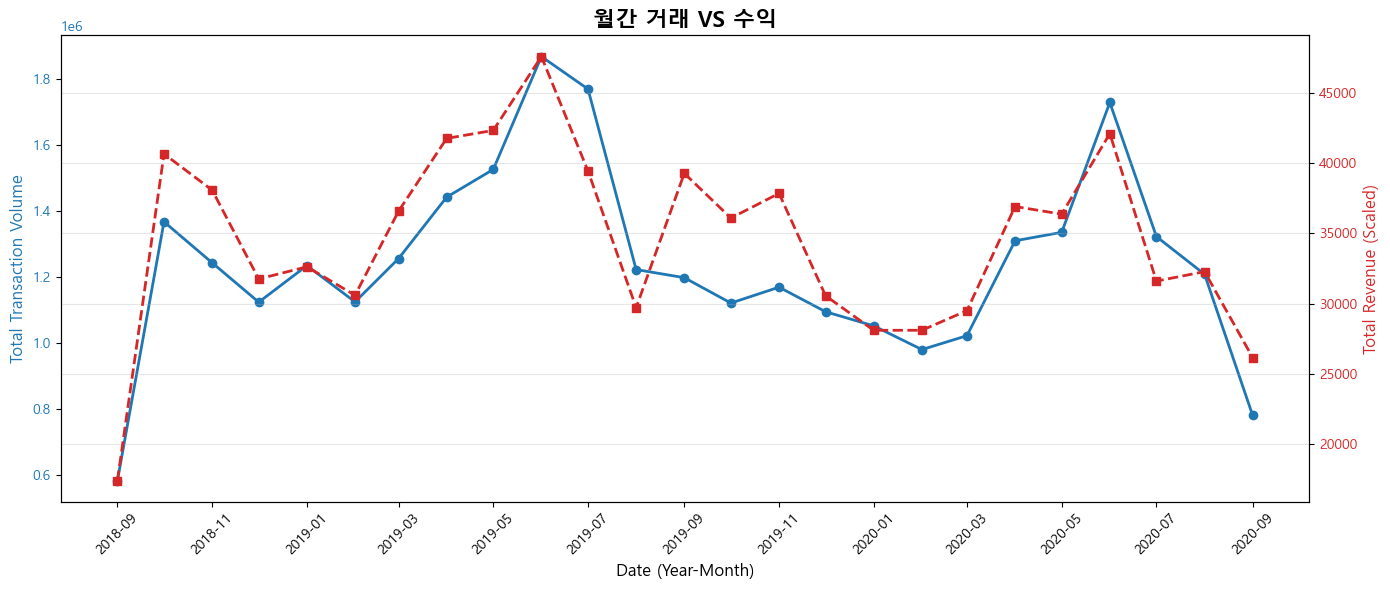

In [11]:
import matplotlib.dates as mdates

# 데이터 로드
transactions = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\transactions.parquet')

transactions['year_month'] = transactions['t_dat'].dt.to_period('M') # 연-월 컬럼 생성 및 월별 집계
monthly_summary = transactions.groupby('year_month').agg(
    total_sales=('article_id', 'count'),
    total_revenue=('price', 'sum') 
).reset_index()

monthly_summary['year_month'] = monthly_summary['year_month'].dt.to_timestamp() # 시각화를 위해 datetime으로 변환

# 시각화 오른쪽 거래량 왼쪽 매출
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Date (Year-Month)', fontsize=12)
ax1.set_ylabel('Total Transaction Volume', color=color, fontsize=12)
ax1.plot(monthly_summary['year_month'], monthly_summary['total_sales'], color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # X축 날짜 포맷팅
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

# 매출을 위한 두 번째 Y축
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Total Revenue (Scaled)', color=color, fontsize=12)
ax2.plot(monthly_summary['year_month'], monthly_summary['total_revenue'], color=color, marker='s', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('월간 거래 VS 수익', fontsize=16, fontweight='bold')
fig.tight_layout()  
plt.grid(True, alpha=0.3)
plt.show()

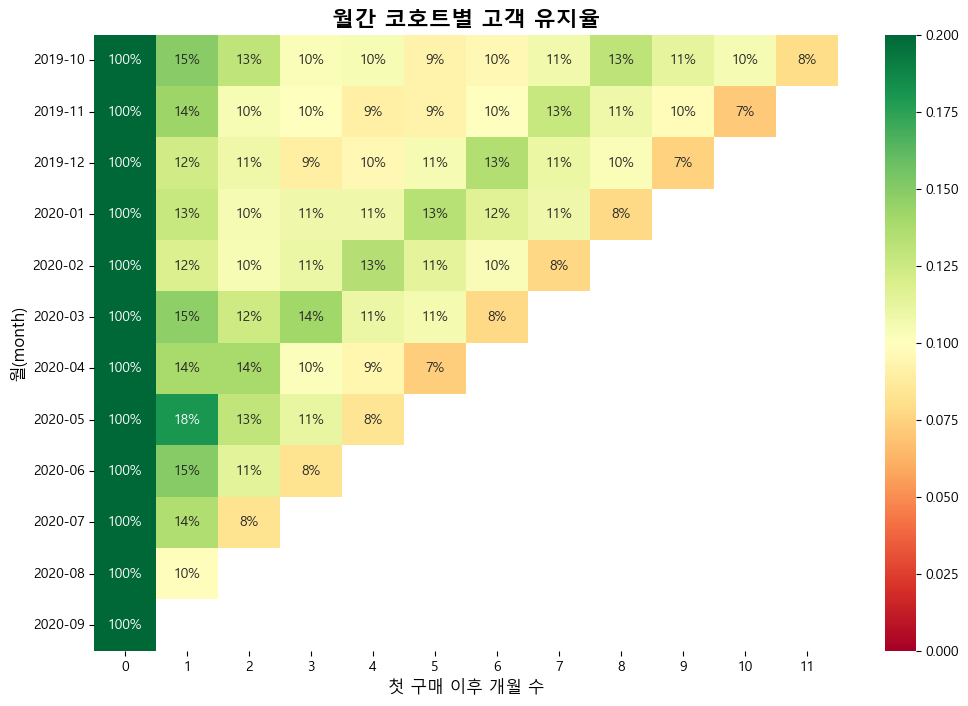

In [12]:
# 고객별 최초 구매월(Cohort Month) 구하기
transactions['cohort_month'] = transactions.groupby('customer_id')['t_dat'].transform('min').dt.to_period('M')
transactions['order_month'] = transactions['t_dat'].dt.to_period('M')

# 코호트별, 주문월별 고객 수 집계
cohort_data = transactions.groupby(['cohort_month', 'order_month']).agg(n_customers=('customer_id', 'nunique')).reset_index()

# 코호트 인덱스(경과 월 수) 계산
cohort_data['period_number'] = (cohort_data.order_month - cohort_data.cohort_month).apply(lambda x: x.n)

# 코호트 피벗 테이블 생성
cohort_pivot = cohort_data.pivot_table(index='cohort_month', columns='period_number', values='n_customers')

# 비율로 변환
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

# 시각화 (가독성을 위해 최근 1년 코호트만, 12개월까지만 시각화)
retention_matrix = retention_matrix.tail(12).iloc[:, :12]

plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0.0, vmax=0.2)
plt.title('월간 코호트별 고객 유지율', fontsize=16, fontweight='bold')
plt.ylabel('월(month)', fontsize=12)
plt.xlabel('첫 구매 이후 개월 수', fontsize=12)
plt.yticks(rotation=0)
plt.show()

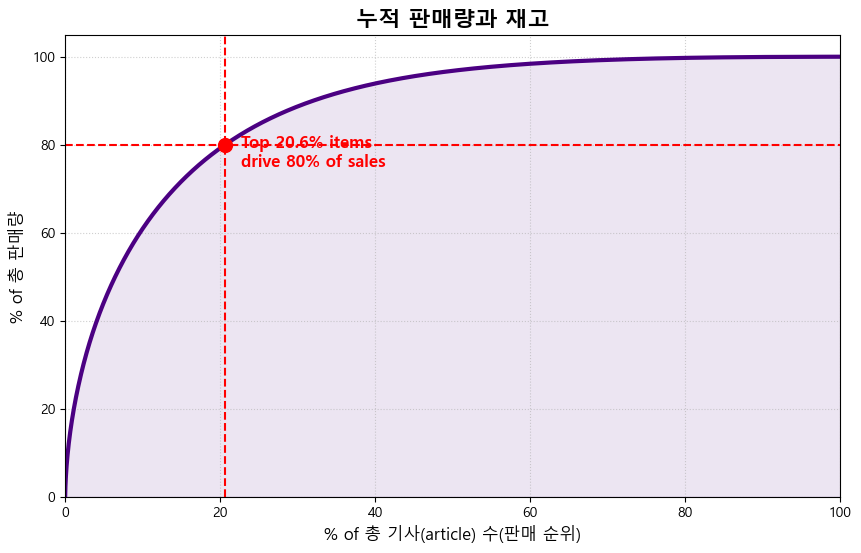

In [13]:
import numpy as np

article_sales = transactions.groupby('article_id').size().reset_index(name='sales_volume')
article_sales = article_sales.sort_values(by='sales_volume', ascending=False).reset_index(drop=True)

article_sales['cumulative_sales'] = article_sales['sales_volume'].cumsum()
article_sales['sales_ratio'] = article_sales['cumulative_sales'] / article_sales['sales_volume'].sum() * 100

article_sales['cumulative_articles'] = np.arange(1, len(article_sales) + 1)
article_sales['article_ratio'] = article_sales['cumulative_articles'] / len(article_sales) * 100

# 80% 비율 찾기
pareto_point = article_sales[article_sales['sales_ratio'] >= 80].iloc[0]

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(article_sales['article_ratio'], article_sales['sales_ratio'], color='indigo', linewidth=3)

# 80% 기준선 강조 코드
plt.axhline(y=80, color='r', linestyle='--')
plt.axvline(x=pareto_point['article_ratio'], color='r', linestyle='--')
plt.scatter(pareto_point['article_ratio'], 80, color='red', s=100, zorder=5)

plt.text(pareto_point['article_ratio'] + 2, 75, f"Top {pareto_point['article_ratio']:.1f}% items\ndrive 80% of sales", 
         fontsize=12, color='red', fontweight='bold')

plt.fill_between(article_sales['article_ratio'], article_sales['sales_ratio'], alpha=0.1, color='indigo')

plt.title('누적 판매량과 재고', fontsize=16, fontweight='bold')
plt.xlabel('% of 총 기사(article) 수(판매 순위)', fontsize=12)
plt.ylabel('% of 총 판매량', fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()